In [2]:
PROJECT_ROOT = "../sequence_to_svm_minimal"

# For amp/decoy length test
AMP_PATH = f"{PROJECT_ROOT}/data/gnn_training_dataset/normalized_combined_set/amps.fasta"
DECOY_PATH = f"{PROJECT_ROOT}/data/gnn_training_dataset/normalized_combined_set/decoys.fasta"

# For AA counts
TRAIN_CSV = f"{PROJECT_ROOT}/data/gnn_training_dataset/normalized_combined_set/generated/geometric_features.csv"
TEST_CSV = f"{PROJECT_ROOT}/data/test/PDDP_candidates/generated/model_comparison_latest.csv"


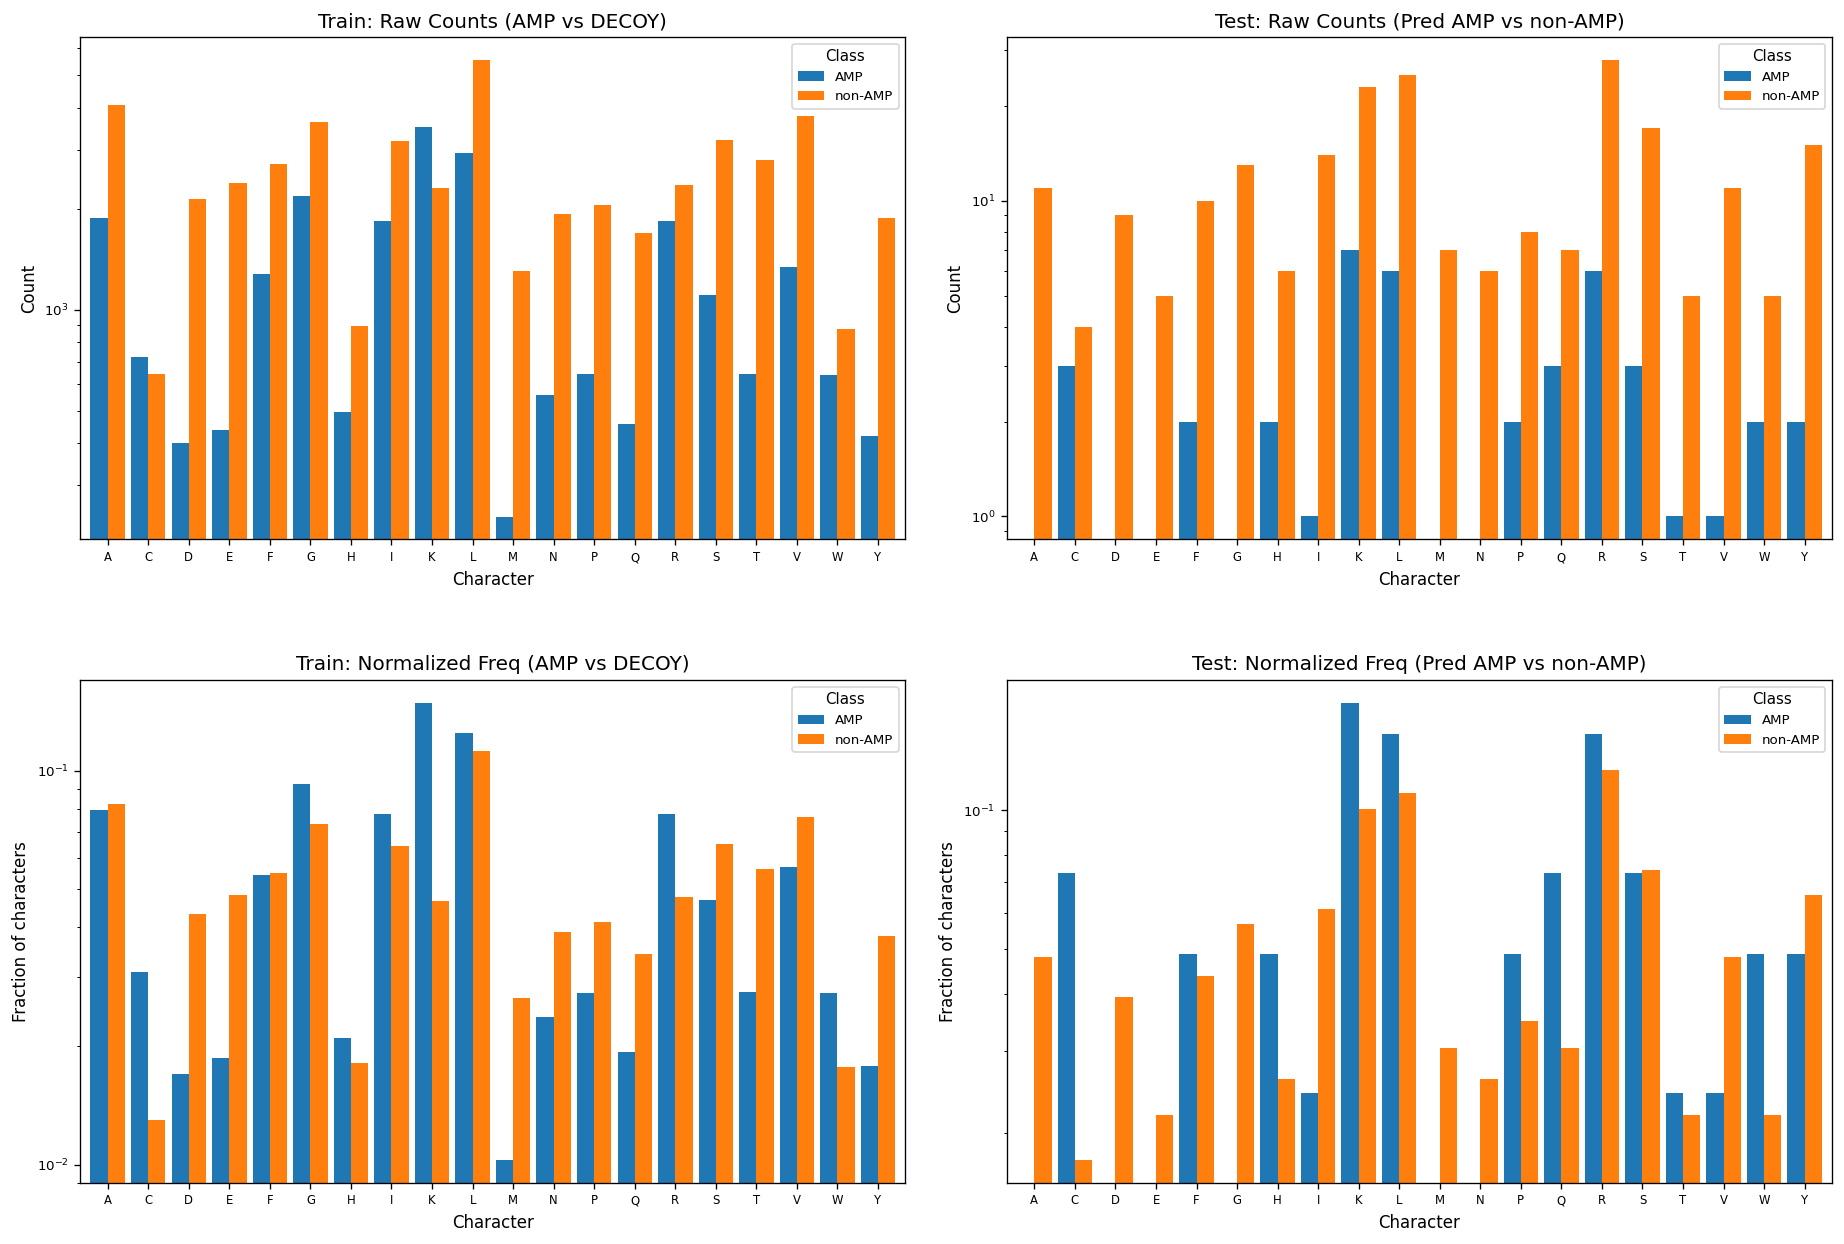

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

TRAIN_GEOM_CSV = Path(TRAIN_CSV)
TEST_GEOM_CSV = Path(TEST_CSV)

STANDARD_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")


def _char_counts(seqs: pd.Series) -> pd.Series:
    seqs = seqs.dropna().astype(str)
    c = Counter()
    for s in seqs:
        c.update(s)
    return pd.Series(dict(c), dtype=int)


def _plot_order(keys: list[str]) -> list[str]:
    key_set = set(keys)
    extras = sorted(k for k in key_set if k not in STANDARD_AA_ORDER)
    return [k for k in STANDARD_AA_ORDER if k in key_set] + extras


def _split_amp_nonamp(
    df: pd.DataFrame,
    *,
    split_pred_col: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, str, str]:
    peptide_ids = df["peptide_id"].astype(str)
    has_amp_id = peptide_ids.str.startswith("AMP_").any()
    has_decoy_id = peptide_ids.str.startswith("DECOY_").any()

    if split_pred_col is not None:
        if split_pred_col not in df.columns:
            raise ValueError(
                f"Requested split_pred_col={split_pred_col!r} not found. Available columns: {list(df.columns)}"
            )
        amp_df = df[df[split_pred_col] == 1]
        non_amp_df = df[df[split_pred_col] == 0]
        return amp_df, non_amp_df, "AMP", "non-AMP"

    if has_amp_id or has_decoy_id:
        amp_df = df[peptide_ids.str.startswith("AMP_")]
        non_amp_df = df[peptide_ids.str.startswith("DECOY_")]
        return amp_df, non_amp_df, "AMP", "non-AMP"

    if "label" in df.columns and set(df["label"].dropna().unique()) >= {0, 1}:
        amp_df = df[df["label"] == 1]
        non_amp_df = df[df["label"] == 0]
        return amp_df, non_amp_df, "AMP", "non-AMP"

    raise ValueError(
        "No way to split AMP vs non-AMP. Provide split_pred_col=... or ensure AMP_/DECOY_ ids or label column exist."
    )


def _counts_df(amp_df: pd.DataFrame, non_amp_df: pd.DataFrame, amp_label: str, non_amp_label: str) -> pd.DataFrame:
    amp_counts = _char_counts(amp_df["sequence"])
    non_amp_counts = _char_counts(non_amp_df["sequence"])
    plot_df = pd.DataFrame({amp_label: amp_counts, non_amp_label: non_amp_counts}).fillna(0)
    order = _plot_order(list(plot_df.index))
    return plot_df.loc[order]


def _plot_counts(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    *,
    title: str,
    ylabel: str,
) -> None:
    plot_df.plot(kind="bar", width=0.85, ax=ax)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Character")
    ax.set_ylabel(ylabel)
    ax.legend(title="Class", fontsize=8, title_fontsize=9)
    ax.tick_params(axis="x", labelrotation=0, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)


def _plot_from_csv(
    csv_path: Path,
    *,
    split_pred_col: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, str, str, pd.DataFrame]:
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing file: {csv_path}")

    df = pd.read_csv(csv_path)
    if "peptide_id" not in df.columns or "sequence" not in df.columns:
        raise ValueError(f"Expected columns peptide_id and sequence in {csv_path}. Available columns: {list(df.columns)}")

    amp_df, non_amp_df, amp_label, non_amp_label = _split_amp_nonamp(df, split_pred_col=split_pred_col)
    if amp_df.empty or non_amp_df.empty:
        raise ValueError(
            f"Cannot plot split for {csv_path}: need both classes, got amp_rows={len(amp_df)} non_amp_rows={len(non_amp_df)}"
        )

    counts = _counts_df(amp_df, non_amp_df, amp_label, non_amp_label)
    return amp_df, non_amp_df, amp_label, non_amp_label, counts


# 2x2 grid: raw counts vs normalized by class size
fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=120, sharex=False)
(ax_train_raw, ax_test_raw), (ax_train_norm, ax_test_norm) = axes

_, _, amp_label_tr, non_amp_label_tr, train_counts = _plot_from_csv(TRAIN_GEOM_CSV)
_plot_counts(
    ax_train_raw,
    train_counts,
    title="Train: Raw Counts (AMP vs DECOY)",
    ylabel="Count",
)

# Normalize by total characters per class
train_norm = train_counts.div(train_counts.sum(axis=0), axis=1)
_plot_counts(
    ax_train_norm,
    train_norm,
    title="Train: Normalized Freq (AMP vs DECOY)",
    ylabel="Fraction of characters",
)

_, _, amp_label_te, non_amp_label_te, test_counts = _plot_from_csv(
    TEST_GEOM_CSV,
    split_pred_col="ESM+Combined32_pred",
)
_plot_counts(
    ax_test_raw,
    test_counts,
    title="Test: Raw Counts (Pred AMP vs non-AMP)",
    ylabel="Count",
)

test_norm = test_counts.div(test_counts.sum(axis=0), axis=1)
_plot_counts(
    ax_test_norm,
    test_norm,
    title="Test: Normalized Freq (Pred AMP vs non-AMP)",
    ylabel="Fraction of characters",
)

plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=2.0)
plt.show()


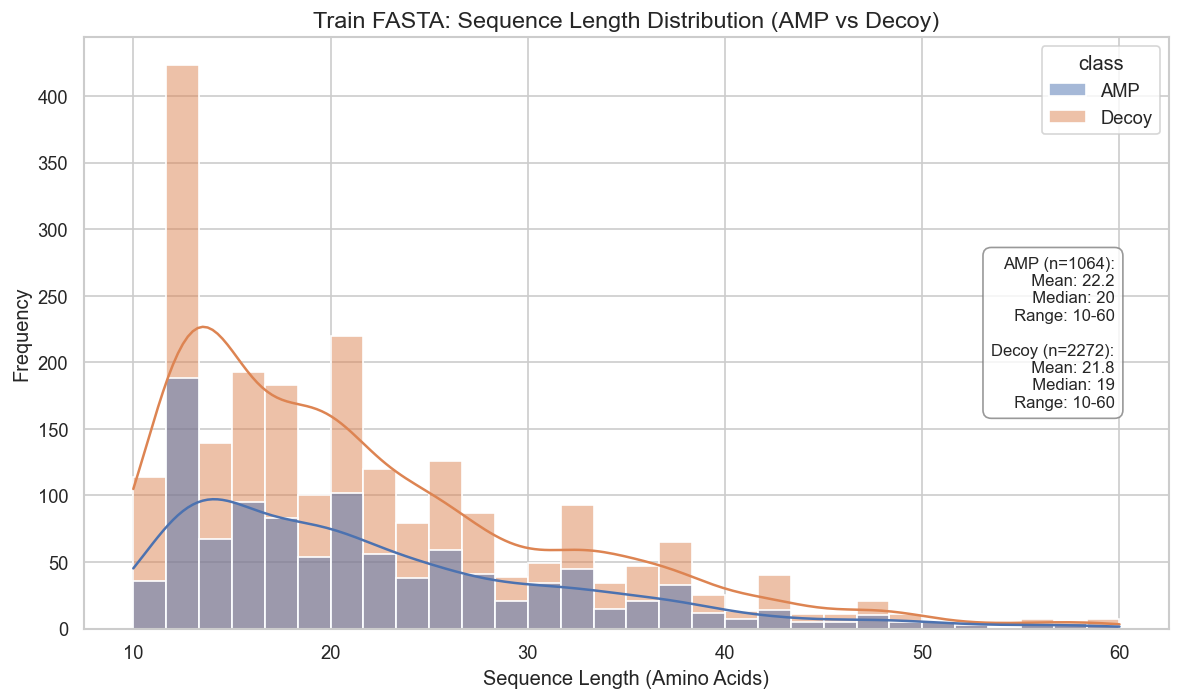

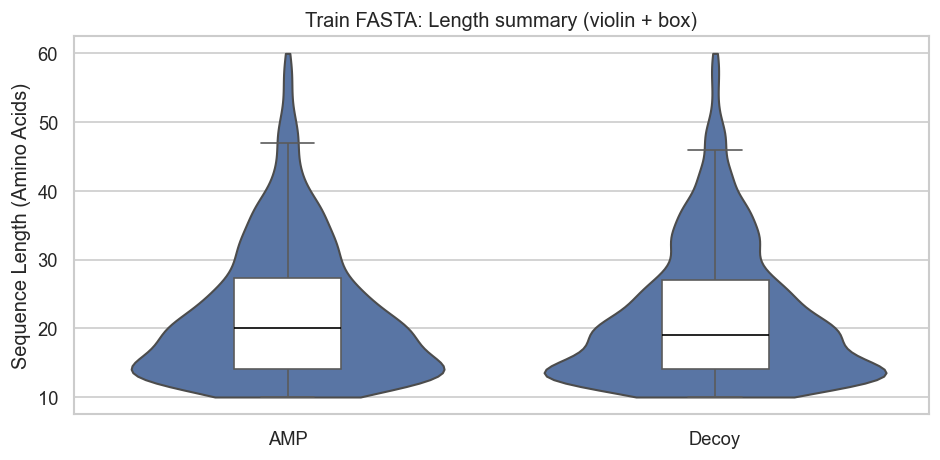

In [4]:
# Peptide length analysis (FASTA baseline): Train AMP vs Decoy
# Ported from: sequence_to_svm_minimal/scripts/data_evaluation/analyze_fasta_lengths.py

import seaborn as sns

AMP_FASTA = Path(AMP_PATH)
DECOY_FASTA = Path(DECOY_PATH)


def parse_fasta_lengths(fasta_path: Path) -> list[int]:
    """Parse a FASTA file and return a list of sequence lengths."""
    lengths: list[int] = []
    current_len = 0
    with open(fasta_path, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_len > 0:
                    lengths.append(current_len)
                    current_len = 0
            else:
                current_len += len(line.replace(" ", "").replace("\n", ""))

        if current_len > 0:
            lengths.append(current_len)

    return lengths


if not AMP_FASTA.exists():
    raise FileNotFoundError(f"Missing AMP FASTA: {AMP_FASTA}")
if not DECOY_FASTA.exists():
    raise FileNotFoundError(f"Missing decoy FASTA: {DECOY_FASTA}")

amp_lengths = parse_fasta_lengths(AMP_FASTA)
decoy_lengths = parse_fasta_lengths(DECOY_FASTA)

plot_df = pd.DataFrame(
    {
        "class": ["AMP"] * len(amp_lengths) + ["Decoy"] * len(decoy_lengths),
        "length": amp_lengths + decoy_lengths,
    }
)

summary = (
    plot_df.groupby("class")["length"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .sort_index()
)
summary

sns.set_theme(style="whitegrid")

# Plot 1: Histogram + KDE
plt.figure(figsize=(10, 6), dpi=120)

sns.histplot(
    data=plot_df,
    x="length",
    hue="class",
    kde=True,
    alpha=0.5,
    bins=30,
)

plt.title("Train FASTA: Sequence Length Distribution (AMP vs Decoy)", fontsize=14)
plt.xlabel("Sequence Length (Amino Acids)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

stats_lines = []
for cls in ["AMP", "Decoy"]:
    lengths = plot_df.loc[plot_df["class"] == cls, "length"].tolist()
    if not lengths:
        continue
    lengths_sorted = sorted(lengths)
    median = lengths_sorted[len(lengths_sorted) // 2]
    stats_lines.append(
        f"{cls} (n={len(lengths)}):\n"
        f"  Mean: {sum(lengths) / len(lengths):.1f}\n"
        f"  Median: {median}\n"
        f"  Range: {min(lengths)}-{max(lengths)}"
    )

plt.annotate(
    "\n\n".join(stats_lines),
    xy=(0.95, 0.5),
    xycoords="axes fraction",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8),
    ha="right",
    va="center",
)

plt.tight_layout()
plt.show()

# Plot 2: Violin + box summary
plt.figure(figsize=(8, 4), dpi=120)

sns.violinplot(
    data=plot_df,
    x="class",
    y="length",
    inner=None,
    cut=0,
)

sns.boxplot(
    data=plot_df,
    x="class",
    y="length",
    width=0.25,
    showcaps=True,
    boxprops={"facecolor": "white", "zorder": 3},
    showfliers=False,
    whiskerprops={"zorder": 3},
    medianprops={"color": "black", "zorder": 4},
    zorder=3,
)

plt.title("Train FASTA: Length summary (violin + box)")
plt.xlabel("")
plt.ylabel("Sequence Length (Amino Acids)")
plt.tight_layout()
plt.show()


C:\Users\bioin\AppData\Local\Temp\ipykernel_26532\2649045189.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(


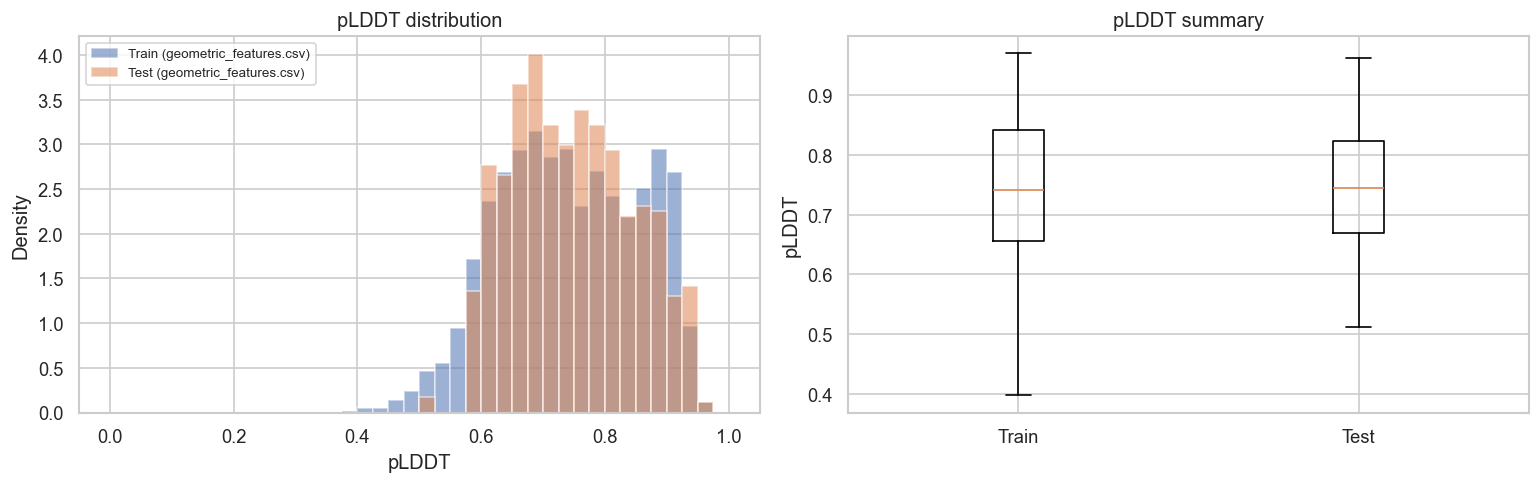

Train pLDDT: ..\sequence_to_svm_minimal\data\gnn_training_dataset\normalized_combined_set\generated\geometric_features.csv (plddt_mean), n=3328
Test pLDDT:  ..\sequence_to_svm_minimal\data\test\CPPs\geometric_features.csv (plddt_mean), n=708


In [6]:
# pLDDT confidence: train vs test
import numpy as np


def _find_first_plddt_csv(candidates: list[Path]) -> tuple[Path, str]:
    for p in candidates:
        if not p.exists():
            continue
        cols = pd.read_csv(p, nrows=5).columns
        if any("plddt" in c.lower() for c in cols):
            return p, p.name
    raise FileNotFoundError(
        "Could not find a CSV with pLDDT columns in candidates:\n" + "\n".join(str(p) for p in candidates)
    )


def _load_plddt_mean(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    plddt_cols = [c for c in df.columns if "plddt" in c.lower()]
    if not plddt_cols:
        raise ValueError(f"No pLDDT columns found in {csv_path}. Available columns: {list(df.columns)}")

    # Prefer mean if available; otherwise take the first pLDDT-like column.
    col = next((c for c in plddt_cols if c.lower() in {"plddt_mean", "mean_plddt"}), plddt_cols[0])
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s.name = col
    return s


train_plddt_path = TRAIN_GEOM_CSV
train_plddt = _load_plddt_mean(train_plddt_path)

# NOTE: TEST_CSV in this notebook points to model prediction comparisons (no pLDDT).
# Fall back to known test geometric feature files when needed.
test_candidates = [
    TEST_GEOM_CSV,
    Path(PROJECT_ROOT) / "data/test/CPPs/geometric_features.csv",
    Path(PROJECT_ROOT) / "data/test/initial_set/geometric_features.csv",
]
test_plddt_path, _ = _find_first_plddt_csv(test_candidates)
test_plddt = _load_plddt_mean(test_plddt_path)

fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(13, 4.2), dpi=120)

max_val = max(train_plddt.max(), test_plddt.max())
if max_val <= 1.0:
    bins = np.linspace(0, 1, 41)
else:
    max_val = max(train_plddt.max(), test_plddt.max())
if max_val <= 1.0:
    bins = np.linspace(0, 1, 41)
else:
    bins = np.linspace(0, 100, 41)
ax_hist.hist(train_plddt, bins=bins, alpha=0.55, density=True, label=f"Train ({train_plddt_path.name})")
ax_hist.hist(test_plddt, bins=bins, alpha=0.55, density=True, label=f"Test ({test_plddt_path.name})")
ax_hist.set_title("pLDDT distribution")
ax_hist.set_xlabel("pLDDT")
ax_hist.set_ylabel("Density")
ax_hist.legend(fontsize=8)

ax_box.boxplot(
    [train_plddt.values, test_plddt.values],
    labels=["Train", "Test"],
    showfliers=False,
)
ax_box.set_title("pLDDT summary")
ax_box.set_ylabel("pLDDT")

plt.tight_layout()
plt.show()

print(f"Train pLDDT: {train_plddt_path} ({train_plddt.name}), n={len(train_plddt)}")
print(f"Test pLDDT:  {test_plddt_path} ({test_plddt.name}), n={len(test_plddt)}")
